# Analysis of screening data (LFC, FDR, p-values)

Notebook for generating log2 fold-change (LFC) values for the screen, as well as empirical p-value calculation relative to the behavior of the non-targetting guides in each library.

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import scipy.stats
import os
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
import warnings
warnings.filterwarnings('ignore')
plt.rc('font', family='Helvetica')

# Generation of LFC tables

- Also determining which values have a low base mean (i.e. very few counts)
    - For this, will work with raw counts
    - Need to make the pipeline flexible enough to run with the different tables

In [319]:
#choose one of conditions as base mean
def col_picker(RPM, base):
    """ 
    RPM = RPM dataframe
    base = choice of base mean for LFC generation; 'DMSO', 'T0', 'Plasmid'
    """

    conditions = list(RPM.columns[1:])

    #generate the base mean columns
    if base not in ['PLASMID', 'Plasmid', 'PLASMID_LIBRARY']:
        if f'{base}_REP1' in conditions:
            prefix = ''
        elif f'CBE_{base}_REP1' in conditions:
            prefix = 'CBE_'
        elif f'ABE_{base}_REP1':
            prefix = 'ABE_'
        
        base_mean_cols = [f'{prefix}{base}_REP1', f'{prefix}{base}_REP2', f'{prefix}{base}_REP3']

    #if it's the plasmid condition as the base mean
    else:
        base_mean_cols = [base]

    #and then generate the groups of conditions to test
    samples_to_test = [i for i in conditions if i not in base_mean_cols]
    samples_to_test = [i[:-5] for i in samples_to_test if i not in ['PLASMID', 'Plasmid', 'PLASMID_LIBRARY']]
    uniq_samps = list(np.unique(samples_to_test))

    #make dict and add back in the plasmid
    if base not in ['PLASMID', 'Plasmid', 'PLASMID_LIBRARY']:
        s = [[f'{i}_REP1', f'{i}_REP2', f'{i}_REP3'] for i in uniq_samps] + [[i] for i in conditions if i in ['PLASMID', 'Plasmid', 'PLASMID_LIBRARY']]
        samp_dict = dict(zip(uniq_samps + ['Plasmid'], s))
    else:
        s = [[f'{i}_REP1', f'{i}_REP2', f'{i}_REP3'] for i in uniq_samps]
        samp_dict = dict(zip(uniq_samps, s))

    return base_mean_cols, samp_dict

In [457]:
def LFC_generator(RPM, raw, base_mean_cols, samp_dict,  pseudocount=1, base_method = 'median'):
    """ 
    Function for generating LFC values from base mean and samp_dict

    RPM, raw = RPM and raw counts dataframes, respectively
    base_mean_cols, samp_dict = generated by col_picker() function
    pseudo_count = # of pseudocounts to add to RPM (numerator and denominator) for log2FC calculation (default = 1)
    base_method = method for determining base count (default = 'median'; also can do 'average')
    """
    
    base = RPM[base_mean_cols]
    base_raw = raw[base_mean_cols]

    if len(base_mean_cols)>1:
        if base_method=='median':
            base_comb = np.median(base, axis=1)
            base_comb_RAW = np.median(base_raw, axis=1)
        elif base_method=='average':
            base_comb = np.average(base, axis=1)
            base_comb_RAW = np.average(base_raw, axis=1)
        else:
            assert 1==0, print('Choose one of: "median" or "average" for base_method parameter')
    elif len(base_mean_cols)==1:
        print('Plasmid as base value; only one replicate; taking true value as base')
        base_comb = RPM[base_mean_cols[0]]
        base_comb_RAW = raw[base_mean_cols[0]]

    #then iterate through the different samples and generate LFC values from RPM
    #adding pseudocount as well
    conditions = list(samp_dict.keys())
    df_holder2 = []
    #include both the base RPM and base RAW values for filtration downstream
    for condition_of_interest in conditions:

        samp_of_interest = samp_dict[condition_of_interest]

        #calculate log2fc
        lfc_list = []
        for k in samp_of_interest:
            col = RPM[k]
            lfc = np.log2((col+pseudocount)/(base_comb+pseudocount)) #LFC with pseudocount

            lfc_list.append(lfc)

        lfc_table = pd.DataFrame(dict(zip(samp_of_interest, lfc_list)))
        lfc_table[f'LFC_avg_{condition_of_interest}'] = np.average(lfc_table[samp_of_interest], axis=1)
        lfc_table[f'LFC_median_{condition_of_interest}'] = np.median(lfc_table[samp_of_interest], axis=1)
        lfc_table['base_RPM'] = base_comb
        lfc_table['base_RAW'] = base_comb_RAW
        ids = RPM[['gRNA_id']]

        LFC_df = pd.concat((ids, lfc_table), axis=1)
        df_holder2.append(LFC_df)
    
    combined_LFC = pd.concat(df_holder2, axis=1)
    combined_LFC = combined_LFC.loc[:,~combined_LFC.columns.duplicated()].copy()

    return combined_LFC


In [399]:
import numpy as np
from scipy.stats import combine_pvalues
from statsmodels.stats.multitest import multipletests


def one_sided_FDR_v2(null_gRNA_ids, samp_dict, condition_of_interest, LFC_df, num_boot=10000):
    """ 
    Function for calculation of empirical p-values and FDR values
    Based on rank relative to null distribution of gRNA LFC values (from non-targetting guides above given raw base-mean count)

    null_gRNA_ids = list of gRNA ids for dataframe (PRE-FILTERED FOR BASE COUNTS!)
    samp_dict = generated by col_picker() function
    condition_of_interest = condition of interest/key value for samp_dict
    LFC_df = LFC dataframe generated by LFC_generator()
    num_boot = # of bootstrapping samples for null distribution
    
    """
    print(condition_of_interest)
    # generate null distribution from NT-gRNAs (e.g., log2 fold changes)
    samp_of_interest = samp_dict[condition_of_interest]
    non_targ = LFC_df[LFC_df['gRNA_id'].isin(null_gRNA_ids)].reset_index(drop=True)
    data = non_targ[samp_of_interest].to_numpy().flatten()
    print(len(data))
    nt_gRNA_values = np.random.choice(data, size=num_boot, replace=True)
    print(len(nt_gRNA_values))

    #targeting gRNAs with 3 replicates per guide
    #including NT gRNAs here for completeness even though they're in the null distribution
    gRNA_values = np.asarray(LFC_df[samp_of_interest])

    # Function to compute empirical two-tailed p-values
    def empirical_p_value(observed, null_distribution):
        S_high = sum(null_distribution >= observed)
        S_low = sum(null_distribution <= observed)
        N = len(null_distribution)

        # Compute two-sided p-value
        p_high = (S_high + 1) / (N + 1)
        p_low = (S_low + 1) / (N + 1)
        return p_high, p_low

    # Compute p-values for each replicate separately (two-tailed)
    p_values_high = np.array([
        [empirical_p_value(rep, nt_gRNA_values)[0] for rep in gRNA] 
        for gRNA in gRNA_values
    ])

    p_values_low = np.array([
        [empirical_p_value(rep, nt_gRNA_values)[1] for rep in gRNA] 
        for gRNA in gRNA_values
    ])

    # Combine p-values across replicates using Fisher's method
    combined_p_values_high = np.array([
        combine_pvalues(p_vals, method='fisher')[1] for p_vals in p_values_high
    ])
    
    combined_p_values_low = np.array([
        combine_pvalues(p_vals, method='fisher')[1] for p_vals in p_values_low
    ])

    # Adjust for multiple testing (Benjamini-Hochberg FDR)
    adjusted_p_values_high = multipletests(combined_p_values_high, method='fdr_bh')[1]
    adjusted_p_values_low = multipletests(combined_p_values_low, method='fdr_bh')[1]

    # Store results in the dataframe
    #LFC_df[f'p_high_unadjusted_{condition_of_interest}'] = combined_p_values_high
    #LFC_df[f'p_low_unadjusted_{condition_of_interest}'] = combined_p_values_low
    #LFC_df[f'FDR_high_{condition_of_interest}'] = adjusted_p_values_high
    #LFC_df[f'FDR_low_{condition_of_interest}'] = adjusted_p_values_low
    LFC_df[f'p_{condition_of_interest}'] = [min(combined_p_values_high[i], combined_p_values_low[i]) for i in range(len(combined_p_values_high))]
    LFC_df[f'FDR_{condition_of_interest}'] = [min(adjusted_p_values_high[i], adjusted_p_values_low[i]) for i in range(len(adjusted_p_values_high))]

    return LFC_df #, p_values_per_replicate

# Barcode Count LFC/FDR

- Using 100 raw counts as base mean for all of these

## A. DMSO as base mean

In [431]:
library = pd.read_csv('../../source_data/02_library/CDK_library_final.csv')
library.loc[library['classification']=='non-targeting control', 'Gene']='NT'

#options = 'barcode', 'proto', 'matched'
count_type = 'barcode'
ct_dict = {'barcode':'bc', 'proto':'proto', 'matched':'matched'}
base = 'DMSO'
min_base_counts = 100

save_filepath = f'../../screening_data/03_LFC_FDR_tables/{count_type}_counts/{base}_base'

#screen samples list
samples = ['CBE_subpool1',
 'ABE_subpool1',
 'CDK12_13_CBE',
 'CDK12_13_ABE',
 'Compound_mutant',
 'SY_5609_CBE',
 'SY_5609_ABE']


for sample in samples:

    fp_RPM = f'../../screening_data/02_RPM_tables/{count_type}_counts'
    fp_raw = f'../../screening_data/01_count_tables/{count_type}_counts'

    RPM = pd.read_csv(f'{fp_RPM}/{sample}_{ct_dict[count_type]}_counts_RPM.csv')
    raw = pd.read_csv(f'{fp_raw}/{sample}_{ct_dict[count_type]}_counts.csv')

    #choose the right base
    if base=='Plasmid':
        c = list(RPM.columns[1:])

        if 'Plasmid' in c:
            base2 = 'Plasmid'
        elif 'PLASMID' in c:
            base2='PLASMID'
        elif 'PLASMID_LIBRARY' in c:
            base2 = 'PLASMID_LIBRARY'
        else:
            assert 1==0, print('Error in Plasmid column id')
    elif base!='Plasmid':
        base2 = base

    base_mean_cols, samp_dict = col_picker(RPM, base2)
    
    LFC1 = LFC_generator(RPM, raw, base_mean_cols, samp_dict,  pseudocount=1, base_method = 'median')

    #add info about gRNAs
    LFC = pd.merge(library[['gRNA_id', 'Gene', 'classification']], LFC1, on='gRNA_id')

    #select non-targeting guides
    null_gRNA_ids = list(LFC[(LFC['classification']=='non-targeting control') & (LFC['base_RAW']>=min_base_counts)]['gRNA_id'])

    LFC_FDR_holder = []

    for condition_of_interest in list(samp_dict.keys()):

        s1 = one_sided_FDR_v2(null_gRNA_ids, samp_dict, condition_of_interest, LFC, num_boot=10000)
        LFC_FDR_holder.append(s1)

    combined_LFC = pd.concat(LFC_FDR_holder, axis=1)
    combined_LFC = combined_LFC.loc[:,~combined_LFC.columns.duplicated()].copy()

    combined_LFC.to_csv(f'{save_filepath}/{sample}_barcode_{base}_base.csv', index=False)

KB-0742_1500nM
393
10000
KI-CDK9d-32N_1250nM
393
10000
KI-CDK9d-32N_5000nM
393
10000
KI-CDK9d-32_1000nM
393
10000
KI-CDK9d-32_100nM
393
10000
SEL120_4000nM
393
10000
Senexin B_15000nM
393
10000
Senexin B_2000nM
393
10000
T0
393
10000
Plasmid
131
10000
KB-0742_1500nM
393
10000
KI-CDK9d-32N_1250nM
393
10000
KI-CDK9d-32N_5000nM
393
10000
KI-CDK9d-32_1000nM
393
10000
KI-CDK9d-32_100nM
393
10000
SEL120_4000nM
393
10000
Senexin B_15000nM
393
10000
Senexin B_2000nM
393
10000
T0
393
10000
Plasmid
131
10000
CBE_BSJ-4-116
675
10000
CBE_CDK12-IN-2
675
10000
CBE_HQ461
675
10000
CBE_T0
675
10000
Plasmid
225
10000
ABE_BSJ-4-116
696
10000
ABE_CDK12-IN-2
696
10000
ABE_HQ461
696
10000
ABE_T0
696
10000
Plasmid
232
10000
KB_2000
393
10000
KB_4000
393
10000
T0
393
10000
Plasmid
131
10000
CBE_SY-5609_100nM
393
10000
CBE_SY-5609_10nM
393
10000
CBE_T0
393
10000
Plasmid
131
10000
ABE_SY-5609_100nM
390
10000
ABE_SY-5609_10nM
390
10000
ABE_T0
390
10000
Plasmid
130
10000


## B. Plasmid as base mean

Need some subtle changes to deal with the difference in plasmid column naming scheme.

In [458]:
library = pd.read_csv('../../source_data/02_library/CDK_library_final.csv')
library.loc[library['classification']=='non-targeting control', 'Gene']='NT'

#options = 'barcode', 'proto', 'matched'
count_type = 'barcode'
ct_dict = {'barcode':'bc', 'proto':'proto', 'matched':'matched'}
base = 'Plasmid'
min_base_counts = 100

save_filepath = f'../../screening_data/03_LFC_FDR_tables/{count_type}_counts/{base}_base'

#screen samples list
samples = ['CBE_subpool1',
 'ABE_subpool1',
 'CDK12_13_CBE',
 'CDK12_13_ABE',
 'Compound_mutant',
 'SY_5609_CBE',
 'SY_5609_ABE']


for sample in samples:

    fp_RPM = f'../../screening_data/02_RPM_tables/{count_type}_counts'
    fp_raw = f'../../screening_data/01_count_tables/{count_type}_counts'

    RPM = pd.read_csv(f'{fp_RPM}/{sample}_{ct_dict[count_type]}_counts_RPM.csv')
    raw = pd.read_csv(f'{fp_raw}/{sample}_{ct_dict[count_type]}_counts.csv')

    #choose the right base
    if base=='Plasmid':
        c = list(RPM.columns[1:])

        if 'Plasmid' in c:
            base2 = 'Plasmid'
        elif 'PLASMID' in c:
            base2='PLASMID'
        elif 'PLASMID_LIBRARY' in c:
            base2 = 'PLASMID_LIBRARY'
        else:
            assert 1==0, print('Error in Plasmid column id')
    elif base!='Plasmid':
        base2 = base

    base_mean_cols, samp_dict = col_picker(RPM, base2)
    
    LFC1 = LFC_generator(RPM, raw, base_mean_cols, samp_dict,  pseudocount=1, base_method = 'median')

    #add info about gRNAs
    LFC = pd.merge(library[['gRNA_id', 'Gene', 'classification']], LFC1, on='gRNA_id')

    #select non-targeting guides
    null_gRNA_ids = list(LFC[(LFC['classification']=='non-targeting control') & (LFC['base_RAW']>=min_base_counts)]['gRNA_id'])

    LFC_FDR_holder = []

    for condition_of_interest in list(samp_dict.keys()):

        s1 = one_sided_FDR_v2(null_gRNA_ids, samp_dict, condition_of_interest, LFC, num_boot=10000)
        LFC_FDR_holder.append(s1)

    combined_LFC = pd.concat(LFC_FDR_holder, axis=1)
    combined_LFC = combined_LFC.loc[:,~combined_LFC.columns.duplicated()].copy()

    combined_LFC.to_csv(f'{save_filepath}/{sample}_barcode_{base}_base.csv', index=False)

Plasmid as base value; only one replicate; taking true value as base
DMSO
393
10000
KB-0742_1500nM
393
10000
KI-CDK9d-32N_1250nM
393
10000
KI-CDK9d-32N_5000nM
393
10000
KI-CDK9d-32_1000nM
393
10000
KI-CDK9d-32_100nM
393
10000
SEL120_4000nM
393
10000
Senexin B_15000nM
393
10000
Senexin B_2000nM
393
10000
T0
393
10000
Plasmid as base value; only one replicate; taking true value as base
DMSO
393
10000
KB-0742_1500nM
393
10000
KI-CDK9d-32N_1250nM
393
10000
KI-CDK9d-32N_5000nM
393
10000
KI-CDK9d-32_1000nM
393
10000
KI-CDK9d-32_100nM
393
10000
SEL120_4000nM
393
10000
Senexin B_15000nM
393
10000
Senexin B_2000nM
393
10000
T0
393
10000
Plasmid as base value; only one replicate; taking true value as base
CBE_BSJ-4-116
705
10000
CBE_CDK12-IN-2
705
10000
CBE_DMSO
705
10000
CBE_HQ461
705
10000
CBE_T0
705
10000
Plasmid as base value; only one replicate; taking true value as base
ABE_BSJ-4-116
705
10000
ABE_CDK12-IN-2
705
10000
ABE_DMSO
705
10000
ABE_HQ461
705
10000
ABE_T0
705
10000
Plasmid as base 

## C. T0 as base mean

In [459]:
library = pd.read_csv('../../source_data/02_library/CDK_library_final.csv')
library.loc[library['classification']=='non-targeting control', 'Gene']='NT'

#options = 'barcode', 'proto', 'matched'
count_type = 'barcode'
ct_dict = {'barcode':'bc', 'proto':'proto', 'matched':'matched'}
base = 'T0'
min_base_counts = 100

save_filepath = f'../../screening_data/03_LFC_FDR_tables/{count_type}_counts/{base}_base'

#screen samples list
samples = ['CBE_subpool1',
 'ABE_subpool1',
 'CDK12_13_CBE',
 'CDK12_13_ABE',
 'Compound_mutant',
 'SY_5609_CBE',
 'SY_5609_ABE']


for sample in samples:

    fp_RPM = f'../../screening_data/02_RPM_tables/{count_type}_counts'
    fp_raw = f'../../screening_data/01_count_tables/{count_type}_counts'

    RPM = pd.read_csv(f'{fp_RPM}/{sample}_{ct_dict[count_type]}_counts_RPM.csv')
    raw = pd.read_csv(f'{fp_raw}/{sample}_{ct_dict[count_type]}_counts.csv')

    #choose the right base
    if base=='Plasmid':
        c = list(RPM.columns[1:])

        if 'Plasmid' in c:
            base2 = 'Plasmid'
        elif 'PLASMID' in c:
            base2='PLASMID'
        elif 'PLASMID_LIBRARY' in c:
            base2 = 'PLASMID_LIBRARY'
        else:
            assert 1==0, print('Error in Plasmid column id')
    elif base!='Plasmid':
        base2 = base

    base_mean_cols, samp_dict = col_picker(RPM, base2)
    
    LFC1 = LFC_generator(RPM, raw, base_mean_cols, samp_dict,  pseudocount=1, base_method = 'median')

    #add info about gRNAs
    LFC = pd.merge(library[['gRNA_id', 'Gene', 'classification']], LFC1, on='gRNA_id')

    #select non-targeting guides
    null_gRNA_ids = list(LFC[(LFC['classification']=='non-targeting control') & (LFC['base_RAW']>=min_base_counts)]['gRNA_id'])

    LFC_FDR_holder = []

    for condition_of_interest in list(samp_dict.keys()):

        s1 = one_sided_FDR_v2(null_gRNA_ids, samp_dict, condition_of_interest, LFC, num_boot=10000)
        LFC_FDR_holder.append(s1)

    combined_LFC = pd.concat(LFC_FDR_holder, axis=1)
    combined_LFC = combined_LFC.loc[:,~combined_LFC.columns.duplicated()].copy()

    combined_LFC.to_csv(f'{save_filepath}/{sample}_barcode_{base}_base.csv', index=False)

DMSO
390
10000
KB-0742_1500nM
390
10000
KI-CDK9d-32N_1250nM
390
10000
KI-CDK9d-32N_5000nM
390
10000
KI-CDK9d-32_1000nM
390
10000
KI-CDK9d-32_100nM
390
10000
SEL120_4000nM
390
10000
Senexin B_15000nM
390
10000
Senexin B_2000nM
390
10000
Plasmid
130
10000
DMSO
393
10000
KB-0742_1500nM
393
10000
KI-CDK9d-32N_1250nM
393
10000
KI-CDK9d-32N_5000nM
393
10000
KI-CDK9d-32_1000nM
393
10000
KI-CDK9d-32_100nM
393
10000
SEL120_4000nM
393
10000
Senexin B_15000nM
393
10000
Senexin B_2000nM
393
10000
Plasmid
131
10000
CBE_BSJ-4-116
693
10000
CBE_CDK12-IN-2
693
10000
CBE_DMSO
693
10000
CBE_HQ461
693
10000
Plasmid
231
10000
ABE_BSJ-4-116
702
10000
ABE_CDK12-IN-2
702
10000
ABE_DMSO
702
10000
ABE_HQ461
702
10000
Plasmid
234
10000
DMSO
393
10000
KB_2000
393
10000
KB_4000
393
10000
Plasmid
131
10000
CBE_DMSO
390
10000
CBE_SY-5609_100nM
390
10000
CBE_SY-5609_10nM
390
10000
Plasmid
130
10000
ABE_DMSO
390
10000
ABE_SY-5609_100nM
390
10000
ABE_SY-5609_10nM
390
10000
Plasmid
130
10000


# Proto count LFC/FDR
## A. DMSO as base mean

In [460]:
library = pd.read_csv('../../source_data/02_library/CDK_library_final.csv')
library.loc[library['classification']=='non-targeting control', 'Gene']='NT'

#options = 'barcode', 'proto', 'matched'
count_type = 'proto'
ct_dict = {'barcode':'bc', 'proto':'proto', 'matched':'matched'}
base = 'DMSO'
min_base_counts = 100

save_filepath = f'../../screening_data/03_LFC_FDR_tables/{count_type}_counts/{base}_base'

#screen samples list
samples = ['CBE_subpool1',
 'ABE_subpool1',
 'CDK12_13_CBE',
 'CDK12_13_ABE',
 'Compound_mutant',
 'SY_5609_CBE',
 'SY_5609_ABE']


for sample in samples:

    fp_RPM = f'../../screening_data/02_RPM_tables/{count_type}_counts'
    fp_raw = f'../../screening_data/01_count_tables/{count_type}_counts'

    RPM = pd.read_csv(f'{fp_RPM}/{sample}_{ct_dict[count_type]}_counts_RPM.csv')
    raw = pd.read_csv(f'{fp_raw}/{sample}_{ct_dict[count_type]}_counts.csv')

    #choose the right base
    if base=='Plasmid':
        c = list(RPM.columns[1:])

        if 'Plasmid' in c:
            base2 = 'Plasmid'
        elif 'PLASMID' in c:
            base2='PLASMID'
        elif 'PLASMID_LIBRARY' in c:
            base2 = 'PLASMID_LIBRARY'
        else:
            assert 1==0, print('Error in Plasmid column id')
    elif base!='Plasmid':
        base2 = base

    base_mean_cols, samp_dict = col_picker(RPM, base2)
    
    LFC1 = LFC_generator(RPM, raw, base_mean_cols, samp_dict,  pseudocount=1, base_method = 'median')

    #add info about gRNAs
    LFC = pd.merge(library[['gRNA_id', 'Gene', 'classification']], LFC1, on='gRNA_id')

    #select non-targeting guides
    null_gRNA_ids = list(LFC[(LFC['classification']=='non-targeting control') & (LFC['base_RAW']>=min_base_counts)]['gRNA_id'])

    LFC_FDR_holder = []

    for condition_of_interest in list(samp_dict.keys()):

        s1 = one_sided_FDR_v2(null_gRNA_ids, samp_dict, condition_of_interest, LFC, num_boot=10000)
        LFC_FDR_holder.append(s1)

    combined_LFC = pd.concat(LFC_FDR_holder, axis=1)
    combined_LFC = combined_LFC.loc[:,~combined_LFC.columns.duplicated()].copy()

    combined_LFC.to_csv(f'{save_filepath}/{sample}_proto_{base}_base.csv', index=False)

KB-0742_1500nM
393
10000
KI-CDK9d-32N_1250nM
393
10000
KI-CDK9d-32N_5000nM
393
10000
KI-CDK9d-32_1000nM
393
10000
KI-CDK9d-32_100nM
393
10000
SEL120_4000nM
393
10000
Senexin B_15000nM
393
10000
Senexin B_2000nM
393
10000
T0
393
10000
Plasmid
131
10000
KB-0742_1500nM
393
10000
KI-CDK9d-32N_1250nM
393
10000
KI-CDK9d-32N_5000nM
393
10000
KI-CDK9d-32_1000nM
393
10000
KI-CDK9d-32_100nM
393
10000
SEL120_4000nM
393
10000
Senexin B_15000nM
393
10000
Senexin B_2000nM
393
10000
T0
393
10000
Plasmid
131
10000
CBE_BSJ-4-116
699
10000
CBE_CDK12-IN-2
699
10000
CBE_HQ461
699
10000
CBE_T0
699
10000
Plasmid
233
10000
ABE_BSJ-4-116
705
10000
ABE_CDK12-IN-2
705
10000
ABE_HQ461
705
10000
ABE_T0
705
10000
Plasmid
235
10000
KB_2000
393
10000
KB_4000
393
10000
T0
393
10000
Plasmid
131
10000
CBE_SY-5609_100nM
393
10000
CBE_SY-5609_10nM
393
10000
CBE_T0
393
10000
Plasmid
131
10000
ABE_SY-5609_100nM
390
10000
ABE_SY-5609_10nM
390
10000
ABE_T0
390
10000
Plasmid
130
10000


## B. Plasmid as base mean

In [461]:
library = pd.read_csv('../../source_data/02_library/CDK_library_final.csv')
library.loc[library['classification']=='non-targeting control', 'Gene']='NT'

#options = 'barcode', 'proto', 'matched'
count_type = 'proto'
ct_dict = {'barcode':'bc', 'proto':'proto', 'matched':'matched'}
base = 'Plasmid'
min_base_counts = 100

save_filepath = f'../../screening_data/03_LFC_FDR_tables/{count_type}_counts/{base}_base'

#screen samples list
samples = ['CBE_subpool1',
 'ABE_subpool1',
 'CDK12_13_CBE',
 'CDK12_13_ABE',
 'Compound_mutant',
 'SY_5609_CBE',
 'SY_5609_ABE']


for sample in samples:

    fp_RPM = f'../../screening_data/02_RPM_tables/{count_type}_counts'
    fp_raw = f'../../screening_data/01_count_tables/{count_type}_counts'

    RPM = pd.read_csv(f'{fp_RPM}/{sample}_{ct_dict[count_type]}_counts_RPM.csv')
    raw = pd.read_csv(f'{fp_raw}/{sample}_{ct_dict[count_type]}_counts.csv')

    #choose the right base
    if base=='Plasmid':
        c = list(RPM.columns[1:])

        if 'Plasmid' in c:
            base2 = 'Plasmid'
        elif 'PLASMID' in c:
            base2='PLASMID'
        elif 'PLASMID_LIBRARY' in c:
            base2 = 'PLASMID_LIBRARY'
        else:
            assert 1==0, print('Error in Plasmid column id')
    elif base!='Plasmid':
        base2 = base

    base_mean_cols, samp_dict = col_picker(RPM, base2)
    
    LFC1 = LFC_generator(RPM, raw, base_mean_cols, samp_dict,  pseudocount=1, base_method = 'median')

    #add info about gRNAs
    LFC = pd.merge(library[['gRNA_id', 'Gene', 'classification']], LFC1, on='gRNA_id')

    #select non-targeting guides
    null_gRNA_ids = list(LFC[(LFC['classification']=='non-targeting control') & (LFC['base_RAW']>=min_base_counts)]['gRNA_id'])

    LFC_FDR_holder = []

    for condition_of_interest in list(samp_dict.keys()):

        s1 = one_sided_FDR_v2(null_gRNA_ids, samp_dict, condition_of_interest, LFC, num_boot=10000)
        LFC_FDR_holder.append(s1)

    combined_LFC = pd.concat(LFC_FDR_holder, axis=1)
    combined_LFC = combined_LFC.loc[:,~combined_LFC.columns.duplicated()].copy()

    combined_LFC.to_csv(f'{save_filepath}/{sample}_proto_{base}_base.csv', index=False)

Plasmid as base value; only one replicate; taking true value as base
DMSO
393
10000
KB-0742_1500nM
393
10000
KI-CDK9d-32N_1250nM
393
10000
KI-CDK9d-32N_5000nM
393
10000
KI-CDK9d-32_1000nM
393
10000
KI-CDK9d-32_100nM
393
10000
SEL120_4000nM
393
10000
Senexin B_15000nM
393
10000
Senexin B_2000nM
393
10000
T0
393
10000
Plasmid as base value; only one replicate; taking true value as base
DMSO
393
10000
KB-0742_1500nM
393
10000
KI-CDK9d-32N_1250nM
393
10000
KI-CDK9d-32N_5000nM
393
10000
KI-CDK9d-32_1000nM
393
10000
KI-CDK9d-32_100nM
393
10000
SEL120_4000nM
393
10000
Senexin B_15000nM
393
10000
Senexin B_2000nM
393
10000
T0
393
10000
Plasmid as base value; only one replicate; taking true value as base
CBE_BSJ-4-116
705
10000
CBE_CDK12-IN-2
705
10000
CBE_DMSO
705
10000
CBE_HQ461
705
10000
CBE_T0
705
10000
Plasmid as base value; only one replicate; taking true value as base
ABE_BSJ-4-116
705
10000
ABE_CDK12-IN-2
705
10000
ABE_DMSO
705
10000
ABE_HQ461
705
10000
ABE_T0
705
10000
Plasmid as base 

## C. T0 as base mean

In [462]:
library = pd.read_csv('../../source_data/02_library/CDK_library_final.csv')
library.loc[library['classification']=='non-targeting control', 'Gene']='NT'

#options = 'barcode', 'proto', 'matched'
count_type = 'proto'
ct_dict = {'barcode':'bc', 'proto':'proto', 'matched':'matched'}
base = 'T0'
min_base_counts = 100

save_filepath = f'../../screening_data/03_LFC_FDR_tables/{count_type}_counts/{base}_base'

#screen samples list
samples = ['CBE_subpool1',
 'ABE_subpool1',
 'CDK12_13_CBE',
 'CDK12_13_ABE',
 'Compound_mutant',
 'SY_5609_CBE',
 'SY_5609_ABE']


for sample in samples:

    fp_RPM = f'../../screening_data/02_RPM_tables/{count_type}_counts'
    fp_raw = f'../../screening_data/01_count_tables/{count_type}_counts'

    RPM = pd.read_csv(f'{fp_RPM}/{sample}_{ct_dict[count_type]}_counts_RPM.csv')
    raw = pd.read_csv(f'{fp_raw}/{sample}_{ct_dict[count_type]}_counts.csv')

    #choose the right base
    if base=='Plasmid':
        c = list(RPM.columns[1:])

        if 'Plasmid' in c:
            base2 = 'Plasmid'
        elif 'PLASMID' in c:
            base2='PLASMID'
        elif 'PLASMID_LIBRARY' in c:
            base2 = 'PLASMID_LIBRARY'
        else:
            assert 1==0, print('Error in Plasmid column id')
    elif base!='Plasmid':
        base2 = base

    base_mean_cols, samp_dict = col_picker(RPM, base2)
    
    LFC1 = LFC_generator(RPM, raw, base_mean_cols, samp_dict,  pseudocount=1, base_method = 'median')

    #add info about gRNAs
    LFC = pd.merge(library[['gRNA_id', 'Gene', 'classification']], LFC1, on='gRNA_id')

    #select non-targeting guides
    null_gRNA_ids = list(LFC[(LFC['classification']=='non-targeting control') & (LFC['base_RAW']>=min_base_counts)]['gRNA_id'])

    LFC_FDR_holder = []

    for condition_of_interest in list(samp_dict.keys()):

        s1 = one_sided_FDR_v2(null_gRNA_ids, samp_dict, condition_of_interest, LFC, num_boot=10000)
        LFC_FDR_holder.append(s1)

    combined_LFC = pd.concat(LFC_FDR_holder, axis=1)
    combined_LFC = combined_LFC.loc[:,~combined_LFC.columns.duplicated()].copy()

    combined_LFC.to_csv(f'{save_filepath}/{sample}_proto_{base}_base.csv', index=False)

DMSO
393
10000
KB-0742_1500nM
393
10000
KI-CDK9d-32N_1250nM
393
10000
KI-CDK9d-32N_5000nM
393
10000
KI-CDK9d-32_1000nM
393
10000
KI-CDK9d-32_100nM
393
10000
SEL120_4000nM
393
10000
Senexin B_15000nM
393
10000
Senexin B_2000nM
393
10000
Plasmid
131
10000
DMSO
393
10000
KB-0742_1500nM
393
10000
KI-CDK9d-32N_1250nM
393
10000
KI-CDK9d-32N_5000nM
393
10000
KI-CDK9d-32_1000nM
393
10000
KI-CDK9d-32_100nM
393
10000
SEL120_4000nM
393
10000
Senexin B_15000nM
393
10000
Senexin B_2000nM
393
10000
Plasmid
131
10000
CBE_BSJ-4-116
702
10000
CBE_CDK12-IN-2
702
10000
CBE_DMSO
702
10000
CBE_HQ461
702
10000
Plasmid
234
10000
ABE_BSJ-4-116
705
10000
ABE_CDK12-IN-2
705
10000
ABE_DMSO
705
10000
ABE_HQ461
705
10000
Plasmid
235
10000
DMSO
393
10000
KB_2000
393
10000
KB_4000
393
10000
Plasmid
131
10000
CBE_DMSO
393
10000
CBE_SY-5609_100nM
393
10000
CBE_SY-5609_10nM
393
10000
Plasmid
131
10000
ABE_DMSO
393
10000
ABE_SY-5609_100nM
393
10000
ABE_SY-5609_10nM
393
10000
Plasmid
131
10000


# Matched count LFC/FDR
## A. DMSO as base mean

In [463]:
library = pd.read_csv('../../source_data/02_library/CDK_library_final.csv')
library.loc[library['classification']=='non-targeting control', 'Gene']='NT'

#options = 'barcode', 'proto', 'matched'
count_type = 'matched'
ct_dict = {'barcode':'bc', 'proto':'proto', 'matched':'matched'}
base = 'DMSO'
min_base_counts = 100 #min raw counts for NT gRNA inclusion in null distribution

save_filepath = f'../../screening_data/03_LFC_FDR_tables/{count_type}_counts/{base}_base'

#screen samples list
samples = ['CBE_subpool1',
 'ABE_subpool1',
 'CDK12_13_CBE',
 'CDK12_13_ABE',
 'Compound_mutant',
 'SY_5609_CBE',
 'SY_5609_ABE']


for sample in samples:

    fp_RPM = f'../../screening_data/02_RPM_tables/{count_type}_counts'
    fp_raw = f'../../screening_data/01_count_tables/{count_type}_counts'

    RPM = pd.read_csv(f'{fp_RPM}/{sample}_{ct_dict[count_type]}_counts_RPM.csv')
    raw = pd.read_csv(f'{fp_raw}/{sample}_{ct_dict[count_type]}_counts.csv')

    #choose the right base
    if base=='Plasmid':
        c = list(RPM.columns[1:])

        if 'Plasmid' in c:
            base2 = 'Plasmid'
        elif 'PLASMID' in c:
            base2='PLASMID'
        elif 'PLASMID_LIBRARY' in c:
            base2 = 'PLASMID_LIBRARY'
        else:
            assert 1==0, print('Error in Plasmid column id')
    elif base!='Plasmid':
        base2 = base

    base_mean_cols, samp_dict = col_picker(RPM, base2)
    
    LFC1 = LFC_generator(RPM, raw, base_mean_cols, samp_dict,  pseudocount=1, base_method = 'median')

    #add info about gRNAs
    LFC = pd.merge(library[['gRNA_id', 'Gene', 'classification']], LFC1, on='gRNA_id')

    #select non-targeting guides
    null_gRNA_ids = list(LFC[(LFC['classification']=='non-targeting control') & (LFC['base_RAW']>=min_base_counts)]['gRNA_id'])

    LFC_FDR_holder = []

    for condition_of_interest in list(samp_dict.keys()):

        s1 = one_sided_FDR_v2(null_gRNA_ids, samp_dict, condition_of_interest, LFC, num_boot=10000)
        LFC_FDR_holder.append(s1)

    combined_LFC = pd.concat(LFC_FDR_holder, axis=1)
    combined_LFC = combined_LFC.loc[:,~combined_LFC.columns.duplicated()].copy()

    combined_LFC.to_csv(f'{save_filepath}/{sample}_matched_{base}_base.csv', index=False)

KB-0742_1500nM
393
10000
KI-CDK9d-32N_1250nM
393
10000
KI-CDK9d-32N_5000nM
393
10000
KI-CDK9d-32_1000nM
393
10000
KI-CDK9d-32_100nM
393
10000
SEL120_4000nM
393
10000
Senexin B_15000nM
393
10000
Senexin B_2000nM
393
10000
T0
393
10000
Plasmid
131
10000
KB-0742_1500nM
393
10000
KI-CDK9d-32N_1250nM
393
10000
KI-CDK9d-32N_5000nM
393
10000
KI-CDK9d-32_1000nM
393
10000
KI-CDK9d-32_100nM
393
10000
SEL120_4000nM
393
10000
Senexin B_15000nM
393
10000
Senexin B_2000nM
393
10000
T0
393
10000
Plasmid
131
10000
CBE_BSJ-4-116
648
10000
CBE_CDK12-IN-2
648
10000
CBE_HQ461
648
10000
CBE_T0
648
10000
Plasmid
216
10000
ABE_BSJ-4-116
660
10000
ABE_CDK12-IN-2
660
10000
ABE_HQ461
660
10000
ABE_T0
660
10000
Plasmid
220
10000
KB_2000
390
10000
KB_4000
390
10000
T0
390
10000
Plasmid
130
10000
CBE_SY-5609_100nM
387
10000
CBE_SY-5609_10nM
387
10000
CBE_T0
387
10000
Plasmid
129
10000
ABE_SY-5609_100nM
381
10000
ABE_SY-5609_10nM
381
10000
ABE_T0
381
10000
Plasmid
127
10000


## B. Plasmid as base mean

In [464]:
library = pd.read_csv('../../source_data/02_library/CDK_library_final.csv')
library.loc[library['classification']=='non-targeting control', 'Gene']='NT'

#options = 'barcode', 'proto', 'matched'
count_type = 'matched'
ct_dict = {'barcode':'bc', 'proto':'proto', 'matched':'matched'}
base = 'Plasmid'
min_base_counts = 100 #min raw counts for NT gRNA inclusion in null distribution

save_filepath = f'../../screening_data/03_LFC_FDR_tables/{count_type}_counts/{base}_base'

#screen samples list
samples = ['CBE_subpool1',
 'ABE_subpool1',
 'CDK12_13_CBE',
 'CDK12_13_ABE',
 'Compound_mutant',
 'SY_5609_CBE',
 'SY_5609_ABE']


for sample in samples:

    fp_RPM = f'../../screening_data/02_RPM_tables/{count_type}_counts'
    fp_raw = f'../../screening_data/01_count_tables/{count_type}_counts'

    RPM = pd.read_csv(f'{fp_RPM}/{sample}_{ct_dict[count_type]}_counts_RPM.csv')
    raw = pd.read_csv(f'{fp_raw}/{sample}_{ct_dict[count_type]}_counts.csv')

    #choose the right base
    if base=='Plasmid':
        c = list(RPM.columns[1:])

        if 'Plasmid' in c:
            base2 = 'Plasmid'
        elif 'PLASMID' in c:
            base2='PLASMID'
        elif 'PLASMID_LIBRARY' in c:
            base2 = 'PLASMID_LIBRARY'
        else:
            assert 1==0, print('Error in Plasmid column id')
    elif base!='Plasmid':
        base2 = base

    base_mean_cols, samp_dict = col_picker(RPM, base2)
    
    LFC1 = LFC_generator(RPM, raw, base_mean_cols, samp_dict,  pseudocount=1, base_method = 'median')

    #add info about gRNAs
    LFC = pd.merge(library[['gRNA_id', 'Gene', 'classification']], LFC1, on='gRNA_id')

    #select non-targeting guides
    null_gRNA_ids = list(LFC[(LFC['classification']=='non-targeting control') & (LFC['base_RAW']>=min_base_counts)]['gRNA_id'])

    LFC_FDR_holder = []

    for condition_of_interest in list(samp_dict.keys()):

        s1 = one_sided_FDR_v2(null_gRNA_ids, samp_dict, condition_of_interest, LFC, num_boot=10000)
        LFC_FDR_holder.append(s1)

    combined_LFC = pd.concat(LFC_FDR_holder, axis=1)
    combined_LFC = combined_LFC.loc[:,~combined_LFC.columns.duplicated()].copy()

    combined_LFC.to_csv(f'{save_filepath}/{sample}_matched_{base}_base.csv', index=False)

Plasmid as base value; only one replicate; taking true value as base
DMSO
393
10000
KB-0742_1500nM
393
10000
KI-CDK9d-32N_1250nM
393
10000
KI-CDK9d-32N_5000nM
393
10000
KI-CDK9d-32_1000nM
393
10000
KI-CDK9d-32_100nM
393
10000
SEL120_4000nM
393
10000
Senexin B_15000nM
393
10000
Senexin B_2000nM
393
10000
T0
393
10000
Plasmid as base value; only one replicate; taking true value as base
DMSO
393
10000
KB-0742_1500nM
393
10000
KI-CDK9d-32N_1250nM
393
10000
KI-CDK9d-32N_5000nM
393
10000
KI-CDK9d-32_1000nM
393
10000
KI-CDK9d-32_100nM
393
10000
SEL120_4000nM
393
10000
Senexin B_15000nM
393
10000
Senexin B_2000nM
393
10000
T0
393
10000
Plasmid as base value; only one replicate; taking true value as base
CBE_BSJ-4-116
705
10000
CBE_CDK12-IN-2
705
10000
CBE_DMSO
705
10000
CBE_HQ461
705
10000
CBE_T0
705
10000
Plasmid as base value; only one replicate; taking true value as base
ABE_BSJ-4-116
705
10000
ABE_CDK12-IN-2
705
10000
ABE_DMSO
705
10000
ABE_HQ461
705
10000
ABE_T0
705
10000
Plasmid as base 

## C. T0 as base mean

In [465]:
library = pd.read_csv('../../source_data/02_library/CDK_library_final.csv')
library.loc[library['classification']=='non-targeting control', 'Gene']='NT'

#options = 'barcode', 'proto', 'matched'
count_type = 'matched'
ct_dict = {'barcode':'bc', 'proto':'proto', 'matched':'matched'}
base = 'T0'
min_base_counts = 100 #min raw counts for NT gRNA inclusion in null distribution

save_filepath = f'../../screening_data/03_LFC_FDR_tables/{count_type}_counts/{base}_base'

#screen samples list
samples = ['CBE_subpool1',
 'ABE_subpool1',
 'CDK12_13_CBE',
 'CDK12_13_ABE',
 'Compound_mutant',
 'SY_5609_CBE',
 'SY_5609_ABE']


for sample in samples:

    fp_RPM = f'../../screening_data/02_RPM_tables/{count_type}_counts'
    fp_raw = f'../../screening_data/01_count_tables/{count_type}_counts'

    RPM = pd.read_csv(f'{fp_RPM}/{sample}_{ct_dict[count_type]}_counts_RPM.csv')
    raw = pd.read_csv(f'{fp_raw}/{sample}_{ct_dict[count_type]}_counts.csv')

    #choose the right base
    if base=='Plasmid':
        c = list(RPM.columns[1:])

        if 'Plasmid' in c:
            base2 = 'Plasmid'
        elif 'PLASMID' in c:
            base2='PLASMID'
        elif 'PLASMID_LIBRARY' in c:
            base2 = 'PLASMID_LIBRARY'
        else:
            assert 1==0, print('Error in Plasmid column id')
    elif base!='Plasmid':
        base2 = base

    base_mean_cols, samp_dict = col_picker(RPM, base2)
    
    LFC1 = LFC_generator(RPM, raw, base_mean_cols, samp_dict,  pseudocount=1, base_method = 'median')

    #add info about gRNAs
    LFC = pd.merge(library[['gRNA_id', 'Gene', 'classification']], LFC1, on='gRNA_id')

    #select non-targeting guides
    null_gRNA_ids = list(LFC[(LFC['classification']=='non-targeting control') & (LFC['base_RAW']>=min_base_counts)]['gRNA_id'])

    LFC_FDR_holder = []

    for condition_of_interest in list(samp_dict.keys()):

        s1 = one_sided_FDR_v2(null_gRNA_ids, samp_dict, condition_of_interest, LFC, num_boot=10000)
        LFC_FDR_holder.append(s1)

    combined_LFC = pd.concat(LFC_FDR_holder, axis=1)
    combined_LFC = combined_LFC.loc[:,~combined_LFC.columns.duplicated()].copy()

    combined_LFC.to_csv(f'{save_filepath}/{sample}_matched_{base}_base.csv', index=False)

DMSO
390
10000
KB-0742_1500nM
390
10000
KI-CDK9d-32N_1250nM
390
10000
KI-CDK9d-32N_5000nM
390
10000
KI-CDK9d-32_1000nM
390
10000


KeyboardInterrupt: 

# Empirical p-vals and FDR

Should systematically filter out NT gRNAs that have a low base mean (in whatever the denominator is in the comparison). Should do this as well for the targeting and intron-targeting gRNAs

Should only use the non-targetting guides as the null distribution (can compare results from different comparisons, but intron-targetting guides could have an effect as well)

ALSO THINK ABOUT WHEN THE PSEUDOCOUNT IS ADDED; DON'T NECESSARILY NEED TO DO IT BEFORE THE RPM CALCULATION

(updated the RPM tables such that no pseudocount is added)

https://academic.oup.com/bioinformatics/article/34/23/4054/5040306


In [ ]:
import numpy as np
from scipy.stats import combine_pvalues
from statsmodels.stats.multitest import multipletests


def one_sided_FDR_v2(condition_of_interest, LFC_df, min_DMSO_counts, num_boot=10000):
    # null distribution from NT-gRNAs (e.g., log2 fold changes)
    samp_of_interest = [f'{condition_of_interest}_REP{i}' for i in range(1,4)]

    #furthermore, add in the intron-targetting gRNAs to the distribution
    introns_NT = ['CDK19_intron', 'CDK9_intron', 'CDK7_intron', 'CDK8_intron', 'NT']

    non_targ = LFC_df[LFC_df['gene'].isin(introns_NT)].reset_index(drop=True)
    #non_targ = LFC_df[LFC_df['gene'].isin(['NT'])].reset_index(drop=True)

    non_targ = non_targ[non_targ['DMSO_median']>=min_DMSO_counts]

    data = non_targ[samp_of_interest].to_numpy().flatten()

    #nt_gRNA_values = data
    print(len(data))
    nt_gRNA_values = np.random.choice(data, size=num_boot, replace=True)
    print(len(nt_gRNA_values))

    #targeting gRNAs with 3 replicates per guide
    #including NT gRNAs here for completeness even though they're in the null distribution
    gRNA_values = np.asarray(LFC_df[samp_of_interest])

    # Function to compute empirical two-tailed p-values
    def empirical_p_value(observed, null_distribution):
        S_high = sum(null_distribution >= observed)
        S_low = sum(null_distribution <= observed)
        N = len(null_distribution)

        # Compute two-sided p-value
        p_high = (S_high + 1) / (N + 1)
        p_low = (S_low + 1) / (N + 1)
        return p_high, p_low

    # Compute p-values for each replicate separately (two-tailed)
    p_values_high = np.array([
        [empirical_p_value(rep, nt_gRNA_values)[0] for rep in gRNA] 
        for gRNA in gRNA_values
    ])

    p_values_low = np.array([
        [empirical_p_value(rep, nt_gRNA_values)[1] for rep in gRNA] 
        for gRNA in gRNA_values
    ])

    # Combine p-values across replicates using Fisher's method
    combined_p_values_high = np.array([
        combine_pvalues(p_vals, method='fisher')[1] for p_vals in p_values_high
    ])
    
    combined_p_values_low = np.array([
        combine_pvalues(p_vals, method='fisher')[1] for p_vals in p_values_low
    ])

    # Adjust for multiple testing (Benjamini-Hochberg FDR)
    adjusted_p_values_high = multipletests(combined_p_values_high, method='fdr_bh')[1]
    adjusted_p_values_low = multipletests(combined_p_values_low, method='fdr_bh')[1]

    # Store results in the dataframe
    #LFC_df[f'p_high_unadjusted_{condition_of_interest}'] = combined_p_values_high
    #LFC_df[f'p_low_unadjusted_{condition_of_interest}'] = combined_p_values_low
    #LFC_df[f'FDR_high_{condition_of_interest}'] = adjusted_p_values_high
    #LFC_df[f'FDR_low_{condition_of_interest}'] = adjusted_p_values_low
    LFC_df[f'p_{condition_of_interest}'] = [min(combined_p_values_high[i], combined_p_values_low[i]) for i in range(len(combined_p_values_high))]
    LFC_df[f'FDR_{condition_of_interest}'] = [min(adjusted_p_values_high[i], adjusted_p_values_low[i]) for i in range(len(adjusted_p_values_high))]

    return LFC_df #, p_values_per_replicate

In [59]:
a = os.listdir('../../screening_data/02_RPM_tables/barcode_counts')
fp = '../../screening_data/02_RPM_tables/barcode_counts'

a2 = pd.read_csv(f'{fp}/{a[4]}')
(a2 == 0).sum()

gRNA_id         0
T0_REP1         1
T0_REP2         0
T0_REP3         0
DMSO_REP1       2
DMSO_REP2       0
DMSO_REP3       1
KB_2000_REP1    2
KB_2000_REP2    0
KB_2000_REP3    3
KB_4000_REP1    2
KB_4000_REP2    1
KB_4000_REP3    2
Plasmid         0
dtype: int64

In [65]:
a = os.listdir('../../screening_data/02_RPM_tables/matched_counts')
fp = '../../screening_data/02_RPM_tables/matched_counts'

a2 = pd.read_csv(f'{fp}/{a[4]}')
(a2 == 0).sum()

gRNA_id          0
T0_REP1          9
T0_REP2          7
T0_REP3          3
DMSO_REP1        5
DMSO_REP2        5
DMSO_REP3        8
KB_2000_REP1    19
KB_2000_REP2    19
KB_2000_REP3    22
KB_4000_REP1    24
KB_4000_REP2    11
KB_4000_REP3    21
Plasmid          0
dtype: int64

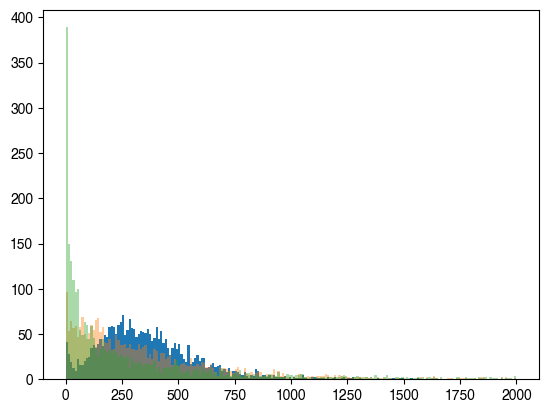

In [76]:
plt.hist(a2['Plasmid'], bins=np.linspace(0,2000,201));
plt.hist(a2['T0_REP1'], bins=np.linspace(0,2000,201), alpha=.4);
plt.hist(a2['KB_2000_REP1'], bins=np.linspace(0,2000,201), alpha=.4);

In [69]:
a2.sort_values(by='KB_2000_REP2')[:20]

,gRNA_id,T0_REP1,T0_REP2,T0_REP3,DMSO_REP1,DMSO_REP2,DMSO_REP3,KB_2000_REP1,KB_2000_REP2,KB_2000_REP3,KB_4000_REP1,KB_4000_REP2,KB_4000_REP3,Plasmid
867,gRNA_CDK8_targ_868,1.323934,14.822341,44.792491,0.590674,4.116731,0.405214,0.273727,0.000000,0.550060,0.000000,1.082083,0.492571,295.106713
2125,gRNA_CDK19_targ_6659,0.330984,0.056359,3.885227,148.981042,0.370506,2.998584,0.273727,0.000000,0.091677,0.068982,5.376600,0.383111,4.248993
2563,gRNA_CDK19_intron_8702,2.316885,128.836013,23.182924,10.960279,22.889024,20.017577,0.273727,0.000000,25.211099,0.344910,39.124063,0.711492,157.099427
2586,gRNA_CDK19_intron_8725,0.082746,3.832392,2.954057,0.721935,0.164669,0.162086,0.000000,0.000000,0.000000,0.000000,0.033815,0.000000,102.315746
570,gRNA_CDK8_targ_571,3.640819,7.777502,2.921947,26.974101,4.240233,9.725138,0.000000,0.000000,0.183353,0.551856,0.000000,0.000000,109.340748
2127,gRNA_CDK19_targ_6661,2.151393,0.056359,8.123656,0.000000,3.705058,0.081043,0.000000,0.000000,0.091677,0.000000,0.541041,0.054730,2.719355
267,gRNA_CDK7_targ_268,10.591473,16.569461,82.007184,1.968912,26.799918,16.775864,0.958043,0.000000,14.118216,10.623230,26.172882,11.766975,158.742371
2129,gRNA_CDK19_targ_6663,0.000000,2.423425,0.000000,1.837652,0.041167,0.243128,0.000000,0.000000,0.000000,0.000000,0.811562,0.000000,15.013108
265,gRNA_CDK7_targ_266,3.475327,0.169076,10.531854,2.100173,4.075564,0.000000,0.821180,0.000000,1.741858,0.068982,0.000000,0.000000,126.450025
2132,gRNA_CDK19_targ_6666,0.000000,0.845381,1.733903,0.262522,0.576342,2.593370,0.000000,0.000000,0.458384,0.965748,35.100067,1.313523,37.107870


# quick and dirty check for CDK12/13

- Try again with matched guide counts or filtering by #of sensor reads?
- Try again with directly using the raw sensor reads in each condition???
    - i.e. estimate LFC with the variants that I'm observing merged into central counts files (at least worth a try again in a BE context)

In [81]:
ABE = pd.read_csv('../../screening_data/02_RPM_tables/barcode_counts/CDK12_13_ABE_bc_counts_RPM.csv')
CBE = pd.read_csv('../../screening_data/02_RPM_tables/barcode_counts/CDK12_13_CBE_bc_counts_RPM.csv')

CBE.columns

Index(['gRNA_id', 'CBE_T0_REP1', 'CBE_T0_REP2', 'CBE_T0_REP3', 'CBE_DMSO_REP1',
       'CBE_DMSO_REP2', 'CBE_DMSO_REP3', 'CBE_BSJ-4-116_REP1',
       'CBE_BSJ-4-116_REP2', 'CBE_BSJ-4-116_REP3', 'CBE_CDK12-IN-2_REP1',
       'CBE_CDK12-IN-2_REP2', 'CBE_CDK12-IN-2_REP3', 'CBE_HQ461_REP1',
       'CBE_HQ461_REP2', 'CBE_HQ461_REP3', 'PLASMID_LIBRARY'],
      dtype='object')

In [88]:
dmso_median_CBE = np.median(CBE[['CBE_DMSO_REP1', 'CBE_DMSO_REP2', 'CBE_DMSO_REP3']], axis=1)
pseudocount = 1

CBE_conditions = [ 'BSJ-4-116','CDK12-IN-2','HQ461']

#CBE_conditions = ['DMSO']

df_holder2 = []

#----------CBE---------
for condition_of_interest in CBE_conditions:

    samp_of_interest = [f'CBE_{condition_of_interest}_REP{i}' for i in range(1,4)]

    #calculate log2fc
    lfc_list = []
    for k in samp_of_interest:
        col = CBE[k]
        lfc = np.log2((col + pseudocount)/(dmso_median_CBE + pseudocount))

        lfc_list.append(lfc)

    lfc_table = pd.DataFrame(dict(zip(samp_of_interest, lfc_list)))
    lfc_table[f'LFC_avg_{condition_of_interest}'] = np.average(lfc_table[samp_of_interest], axis=1)
    lfc_table[f'LFC_median_{condition_of_interest}'] = np.median(lfc_table[samp_of_interest], axis=1)
    lfc_table['DMSO_median'] = dmso_median_CBE
    ids = CBE[['gRNA_id']]

    LFC_df = pd.concat((ids, lfc_table), axis=1)
    df_holder2.append(LFC_df)


combined_LFC = pd.concat(df_holder2, axis=1)
combined_LFC = combined_LFC.loc[:,~combined_LFC.columns.duplicated()].copy()
combined_LFC_CBE = combined_LFC

In [147]:
combined_LFC_CBE.columns

cols = ['gRNA_id', 'DMSO_median','LFC_avg_BSJ-4-116', 'LFC_median_BSJ-4-116',
    'LFC_avg_CDK12-IN-2', 'LFC_median_CDK12-IN-2',
    'LFC_avg_HQ461',
    'LFC_median_HQ461']

combined_LFC_CBE[cols].sort_values(by='LFC_median_HQ461', ascending=False)[:20]

,gRNA_id,DMSO_median,LFC_avg_BSJ-4-116,LFC_median_BSJ-4-116,LFC_avg_CDK12-IN-2,LFC_median_CDK12-IN-2,LFC_avg_HQ461,LFC_median_HQ461
1611,gRNA_CDK12_targ_3351,41.689468,2.345897,2.373575,3.937819,3.996772,6.653031,6.733842
1655,gRNA_CDK12_targ_3395,61.671464,-0.238305,0.180569,0.198580,0.132734,5.104924,5.135279
1654,gRNA_CDK12_targ_3394,5.173406,6.083625,6.255134,5.064700,5.792475,4.782186,4.986456
1656,gRNA_CDK12_targ_3396,55.851040,0.247042,0.948939,-1.131868,-1.692285,4.827208,4.906206
4027,gRNA_CDK13_targ_5767,2.950841,1.890619,1.259007,2.035014,2.630418,3.402643,4.119801
2679,gRNA_CDK13_targ_4419,5.210625,0.522520,0.108702,1.113757,1.314642,2.535654,3.431871
2767,gRNA_CDK13_targ_4507,4.006838,0.393033,0.880964,1.465938,1.133390,3.425329,3.407218
4053,gRNA_CDK13_targ_5793,137.853581,0.022972,-0.181934,1.645759,1.371191,3.280401,3.385792
3056,gRNA_CDK13_targ_4796,2.385751,1.861477,1.676922,2.040516,2.623780,3.168828,3.301426
3135,gRNA_CDK13_targ_4875,2.293991,0.286230,-0.220665,2.126084,1.874045,2.675699,3.219537


In [161]:
e_CBE = pd.read_csv('../../screening_data/CDK12_13_screen_data/editing/D25-188004-1-7191F_guide_split_BARCODES_HGVSp_sensor_quant_v2.csv')

aa = list(combined_LFC_CBE[cols].sort_values(by='LFC_median_HQ461', ascending=False)[:20]['gRNA_id'])
i=12
print(aa[i])
e_CBE[e_CBE['gRNA_id']==aa[i]]

gRNA_CDK12_targ_2105


,Edit,#Reads,HGVSp,Num_edits,DNA Change,Canonical_edit,Canonical_window,gRNA_id
7179,GAAGTATTTTGTTAAAGATT,3,H490Y_L491F,2,"+5C>T,+8C>T,",True,True,gRNA_CDK12_targ_2105
7180,GAAGCATCTTTAGCATTTTG,2,V492*_K493H_D494F_L495V,8,"+11G>T,+12T>A,+13T>G,+14A>C,+16A>T,+17G>T,+18A...",False,False,gRNA_CDK12_targ_2105
7181,GAAGCGTCTTGTTAAAGATT,1,H490R,1,"+6A>G,",False,True,gRNA_CDK12_targ_2105


In [145]:
e_CBE = pd.read_csv('../../screening_data/CDK12_13_screen_data/editing/D25-188004-1-7191F_guide_split_BARCODES_HGVSp_sensor_quant_v2.csv')
e_CBE[e_CBE['gRNA_id']=='gRNA_CDK12_targ_3395']

,Edit,#Reads,HGVSp,Num_edits,DNA Change,Canonical_edit,Canonical_window,gRNA_id
31474,TAGCAGTTCCATTAAGTCAT,53,G822E,1,"+8C>T,",True,True,gRNA_CDK12_targ_3395
31475,TAGCAGTTTCATTAAGTCAT,36,G822K,2,"+8C>T,+9C>T,",True,False,gRNA_CDK12_targ_3395
31476,TAGCAGTCCCATTAAGTCAT,23,WT,0,No edit,True,True,gRNA_CDK12_targ_3395
31477,TAGCAGTTACATTAAGTCAT,11,G822*,2,"+8C>T,+9C>A,",False,False,gRNA_CDK12_targ_3395
31478,TAGCAGTGCCATTAAGTCAT,5,G822A,1,"+8C>G,",False,True,gRNA_CDK12_targ_3395
31479,TAGCAGTCCCATTATCCATA,3,H818L_D819W_L820I,6,"+15A>T,+16G>C,+17T>C,+18C>A,+19A>T,+20T>A,",False,False,gRNA_CDK12_targ_3395
31480,TAGTAGTTTCATTAAGTCAT,3,G822K,3,"+4C>T,+8C>T,+9C>T,",True,False,gRNA_CDK12_targ_3395
31481,TAGCAGTTTTATTAAGTCAT,2,M821I_G822K,3,"+8C>T,+9C>T,+10C>T,",True,False,gRNA_CDK12_targ_3395
31482,TAGTAGTTCCATTAAGTCAT,2,G822E,2,"+4C>T,+8C>T,",True,True,gRNA_CDK12_targ_3395
31483,TAGCAGTCCCATTAAGTTAT,1,D819N,1,"+18C>T,",True,False,gRNA_CDK12_targ_3395


In [92]:
dmso_median_ABE = np.median(ABE[['ABE_DMSO_REP1', 'ABE_DMSO_REP2', 'ABE_DMSO_REP3']], axis=1)


ABE_conditions = [ 'BSJ-4-116','CDK12-IN-2','HQ461']

#CBE_conditions = ['DMSO']

df_holder2 = []

#----------CBE---------
for condition_of_interest in ABE_conditions:

    samp_of_interest = [f'ABE_{condition_of_interest}_REP{i}' for i in range(1,4)]

    #calculate log2fc
    lfc_list = []
    for k in samp_of_interest:
        col = ABE[k]
        lfc =np.log2((col + pseudocount)/(dmso_median_ABE + pseudocount))

        lfc_list.append(lfc)

    lfc_table = pd.DataFrame(dict(zip(samp_of_interest, lfc_list)))
    lfc_table[f'LFC_avg_{condition_of_interest}'] = np.average(lfc_table[samp_of_interest], axis=1)
    lfc_table[f'LFC_median_{condition_of_interest}'] = np.median(lfc_table[samp_of_interest], axis=1)
    lfc_table['DMSO_median'] = dmso_median_ABE
    ids = CBE[['gRNA_id']]

    LFC_df = pd.concat((ids, lfc_table), axis=1)
    df_holder2.append(LFC_df)


combined_LFC = pd.concat(df_holder2, axis=1)
combined_LFC = combined_LFC.loc[:,~combined_LFC.columns.duplicated()].copy()
combined_LFC_ABE = combined_LFC

In [189]:
combined_LFC_ABE.sort_values(by='LFC_median_BSJ-4-116', ascending=False)[cols][:20]

,gRNA_id,DMSO_median,LFC_avg_BSJ-4-116,LFC_median_BSJ-4-116,LFC_avg_CDK12-IN-2,LFC_median_CDK12-IN-2,LFC_avg_HQ461,LFC_median_HQ461
492,gRNA_CDK12_targ_2232,73.276138,6.548474,6.335788,5.136853,5.326954,7.152768,7.317829
2864,gRNA_CDK13_targ_4604,96.766262,4.951133,4.873180,3.591724,3.642793,3.118912,2.660112
545,gRNA_CDK12_targ_2285,114.514356,4.567775,4.365312,-1.403710,-0.873922,0.896584,0.632674
3257,gRNA_CDK13_targ_4997,2.200054,3.815478,3.614585,1.226000,0.692236,-0.652446,-1.344821
493,gRNA_CDK12_targ_2233,57.824745,3.562981,3.445245,2.058542,2.086658,4.003993,3.974405
3281,gRNA_CDK13_targ_5021,4.046667,2.712860,3.158142,1.520261,1.593585,-0.229552,-0.137135
2865,gRNA_CDK13_targ_4605,96.587557,2.855411,2.882840,1.886790,2.343704,2.096051,1.516148
1221,gRNA_CDK12_targ_2961,0.304502,2.426713,2.839823,2.431505,1.885194,-0.113530,-0.058400
712,gRNA_CDK12_targ_2452,18.333780,2.804488,2.777979,0.745818,0.917930,1.685525,3.341302
1612,gRNA_CDK12_targ_3352,79.996924,2.746870,2.767745,-0.727886,-0.540429,0.850403,1.108199


In [197]:
e_ABE = pd.read_csv('../../screening_data/CDK12_13_screen_data/editing/D25-188022-1-7191F_guide_split_BARCODES_HGVSp_sensor_quant_v2.csv')

aa = list(combined_LFC_ABE[cols].sort_values(by='LFC_median_BSJ-4-116', ascending=False)[:20]['gRNA_id'])
i=9
print(aa[i])
e_ABE[e_ABE['gRNA_id']==aa[i]]

gRNA_CDK12_targ_3352


,Edit,#Reads,HGVSp,Num_edits,DNA Change,Canonical_edit,Canonical_window,gRNA_id
32122,GCTTTGTATGCTTGGCCATA,4141,V741A,2,"+6A>G,+10A>G,",True,False,gRNA_CDK12_targ_3352
32123,GCTTTGTGTGCTTGGCCATA,2080,V741A_Y742H,3,"+6A>G,+8A>G,+10A>G,",True,False,gRNA_CDK12_targ_3352
32124,GCTTTGTGTACTTGGCCATA,1390,Y742H,2,"+6A>G,+8A>G,",True,True,gRNA_CDK12_targ_3352
32125,GCTTTGTATACTTGGCCATA,36,WT,1,"+6A>G,",True,True,gRNA_CDK12_targ_3352
32126,GCTTTATATACTTGGCCATA,9,WT,0,No edit,True,True,gRNA_CDK12_targ_3352
...,...,...,...,...,...,...,...,...
32183,GCTTTGTATGCTTGGCGATA,1,G739R_V741A,3,"+6A>G,+10A>G,+17C>G,",False,False,gRNA_CDK12_targ_3352
32184,GCTTTGTATGCTTGGCTATA,1,G739S_V741A,3,"+6A>G,+10A>G,+17C>T,",False,False,gRNA_CDK12_targ_3352
32185,GCTTTGTATTCTTGGCCATA,1,V741E,2,"+6A>G,+10A>T,",False,False,gRNA_CDK12_targ_3352
32186,GCTTTGTGAACTTGGCCATA,1,Y742H,3,"+6A>G,+8A>G,+9T>A,",False,False,gRNA_CDK12_targ_3352
